<a href="https://colab.research.google.com/github/emilioan55/TAREAS-MAESTRIA/blob/main/Actividad2AnalisisPandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 2**
Pandas para el análisis de datos en Python

---

*   NOMBRE: EMILIO ANDRES MENDOZA KAPLAN
*   MATRÍCULA: 00042485


---

En esta actividad trabajarás con el archivo `cleaned_weather.csv`, un extracto del conjunto de datos meteorológicos a lo largo de todo el año 2020 en una estación del Instituto *Max Planck* (Alemania) disponible en Kaggle.

Los datos meteorológicos fueron registrados cada 10 minutos e incluyen los siguientes indicadores:

*   `timestamp`: Fecha y hora de la observación.
*   `p`: Presión atmosférica en milibares (mbar)
*   `T`: Temperatura del aire en grados Celsius (°C)
*   `Tpot`: Temperatura potencial en Kelvin (K)
*   `rh`: Humedad relativa en porcentaje (%)
*   `VPact`: Presión real de vapor en milibares (mbar)
*   `sh`: Humedad específica en gramos por kilogramo (g/kg)
*   `H2OC`: Concentración de vapor de agua en milimoles por mol (mmol/mol) de aire seco
*   `rho`: Densidad del aire en gramos por metro cúbico (g/m³)
*   `wv`: Velocidad del viento en metros por segundo (m/s)
*   `wd`: Dirección del viento en grados (°)
*   `rain`: Precipitación total en milímetros (mm)
*   `raining`: Duración de la lluvia en segundos (s)

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.


In [ ]:
# Importa las librerías necesarias
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1.	Descarga el archivo: `cleaned_weather.csv` y guarda, en un dataframe (`weather_df`), todos sus registros.
- Determina la dimensionalidad del dataframe y obtén los identificadores de columnas.
- Renombra las columnas para facilitar la interpretación de los indicadores en los ejercicios siguientes:
  - `medicion, presion_atmosferica, temperatura_celsius, temperatura_kelvin, humedad_relativa, presion_vapor, humedad_especifica, concentracion_vapor, densidad_aire, velocidad_viento, direccion_viento, precipitacion_total, duracion_lluvia`
- Muestra los primeros y los últimos 5 registros.
- ¿Hay valores faltantes en el dataframe?





**1. DESCARGO EL ARCHIVO CSV**

In [ ]:
weather_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Actividad 2 Analisis Pandas/cleaned_weather.csv')

**DETERMINO LA DIMENSIONALIDAD DEL DATAFRAME**

In [ ]:
weather_df.shape

(52696, 21)

**OBTENGO LOS IDENTIFICADORES DE LAS COLUMNAS**

In [ ]:
weather_df.columns

Index(['date', 'p', 'T', 'Tpot', 'Tdew', 'rh', 'VPmax', 'VPact', 'VPdef', 'sh',
       'H2OC', 'rho', 'wv', 'max. wv', 'wd', 'rain', 'raining', 'SWDR', 'PAR',
       'max. PAR', 'Tlog'],
      dtype='object')

In [ ]:
BM = [True, True, True, True, False, True, False, True, False, True, True, True, True, False, True, True, True, False, False, False, False]

**RENOMBRO LAS COLUMNAS PERO PRIMERO ELIMINO LAS COLUMNAS QUE NO SON DE INTERES**

In [ ]:
weather_df = weather_df.loc[:, BM]

In [ ]:
weather_df.columns

Index(['date', 'p', 'T', 'Tpot', 'rh', 'VPact', 'sh', 'H2OC', 'rho', 'wv',
       'wd', 'rain', 'raining'],
      dtype='object')

In [ ]:
#Renombro las columnas
weather_df.columns = ['medicion', 'presion_atmosferica', 'temperatura_celsius', 'temperatura_kelvin', 'humedad_relativa', 'presion_vapor', 'humedad_especifica', 'concentracion_vapor', 'densidad_aire', 'velocidad_viento', 'direccion_viento', 'precipitacion_total', 'duracion_lluvia']

Ya realizado el cambio

In [ ]:
weather_df.columns

Index(['medicion', 'presion_atmosferica', 'temperatura_celsius',
       'temperatura_kelvin', 'humedad_relativa', 'presion_vapor',
       'humedad_especifica', 'concentracion_vapor', 'densidad_aire',
       'velocidad_viento', 'direccion_viento', 'precipitacion_total',
       'duracion_lluvia'],
      dtype='object')

**MUESTRO LOS PRIMEROS Y LOS ULTIMOS 5 REGISTROS**

In [ ]:
weather_df.head(5)

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
0,2020-01-01 00:10:00,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0.0
1,2020-01-01 00:20:00,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0.0
2,2020-01-01 00:30:00,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0.0
3,2020-01-01 00:40:00,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0.0
4,2020-01-01 00:50:00,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0.0


In [ ]:
weather_df.tail(5)

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
52691,2020-12-31 23:20:00,978.32,2.28,277.16,80.0,5.76,3.67,5.89,1234.61,0.73,180.6,0.0,0.0
52692,2020-12-31 23:30:00,978.30,2.13,277.01,83.1,5.92,3.77,6.05,1235.20,0.43,174.0,0.0,0.0
52693,2020-12-31 23:40:00,978.26,1.99,276.88,82.2,5.80,3.69,5.93,1235.82,0.38,248.9,0.0,0.0
52694,2020-12-31 23:50:00,978.26,2.07,276.95,81.4,5.77,3.68,5.90,1235.49,0.57,196.6,0.0,0.0
52695,2021-01-01 00:00:00,978.24,2.01,276.89,82.4,5.82,3.71,5.95,1235.71,0.57,221.3,0.0,0.0


In [ ]:
#Busco valores faltantes
weather_df.isnull().sum()

,0
medicion,0
presion_atmosferica,0
temperatura_celsius,0
temperatura_kelvin,0
humedad_relativa,0
presion_vapor,0
humedad_especifica,0
concentracion_vapor,0
densidad_aire,0
velocidad_viento,0


No hay valores nulos

2. Determina el tipo de datos que tienen las columnas.
- Cambia la columna `medicion` a datetime utilizando el formato: `%d/%m/%y %H:%M`
- Obtén dos columnas adicionales separando `medicion` en `fecha` y `hora`

**2. DETERMINO EL TIPO DE DATOS QUE TIENEN LAS COLUMNAS**

In [ ]:
#Tipo de datos de cada columna
weather_df.dtypes

,0
medicion,object
presion_atmosferica,float64
temperatura_celsius,float64
temperatura_kelvin,float64
humedad_relativa,float64
presion_vapor,float64
humedad_especifica,float64
concentracion_vapor,float64
densidad_aire,float64
velocidad_viento,float64


**2.1 CAMBIO DE FORMATO A DATETIME**

In [ ]:
#Convierto en formato datetime
weather_df['medicion'] = pd.to_datetime(weather_df['medicion'])

**2.2 SEPARO MEDICION EN DOS COLUMNAS ADICIONALES "fecha" y VERIFICO QUE SE HAYA HECHO CORRECTAMENTE**

In [ ]:
#Separo fecha y almaceno en "fecha"
weather_df['fecha'] = weather_df['medicion'].dt.strftime('%d/%m/%y')

In [ ]:
#Separo HORA y almaceno en "hora"
weather_df['hora'] = weather_df['medicion'].dt.strftime('%H:%M')

In [ ]:
#VERIFICO
weather_df.columns

Index(['medicion', 'presion_atmosferica', 'temperatura_celsius',
       'temperatura_kelvin', 'humedad_relativa', 'presion_vapor',
       'humedad_especifica', 'concentracion_vapor', 'densidad_aire',
       'velocidad_viento', 'direccion_viento', 'precipitacion_total',
       'duracion_lluvia', 'fecha', 'hora'],
      dtype='object')

3. Determina la cantidad de valores únicos de cada columna.
- La columna `medicion` tiene un valor menos que el número total de filas del dataframe, lo que indica que hay una fecha duplicada. Identifica cuál es.
- Comprueba si las demás columnas también contienen los mismos valores; si es así, elimina  uno de los registros duplicados.


**3. DETERMINO LOS VALORES UNICOS EN CADA COLUMNA**

In [ ]:
#Determino la cantidad de valores únicos en cada columna
weather_df.nunique()

,0
medicion,52695
presion_atmosferica,5052
temperatura_celsius,3680
temperatura_kelvin,3836
humedad_relativa,5494
presion_vapor,2059
humedad_especifica,1337
concentracion_vapor,2087
densidad_aire,14826
velocidad_viento,977


**BUSCO EL DUPLICADO EN LA COLUMNA MEDICION**

In [ ]:
#Busco duplicado en la columna medicion
duplicado_exacto = weather_df[weather_df['medicion'].duplicated(keep=False)]
duplicado_exacto

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
19043,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0.0,12/05/20,06:00
19044,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0.0,12/05/20,06:00


**VERIFICO QUE SON LOS MISMOS DATOS, POR LO QUE ELIMINO LA SEGUNDA APARICION**

In [ ]:
#elimino el segundo registro
weather_df = weather_df.drop(19044, axis=0)

4. Imprime nuevamente las cantidad de valores únicos por columna.
- ¿Por qué son 144 horas diferentes?
- La cantidad de combinaciones únicas de fecha y hora no coincide con el número total de mediciones. Aunque no haya valores NaN, esto no garantiza que no se hayan omitido registros. Identifica las fechas en las que faltan mediciones.
- Una vez concluido el análisis de mediciones faltantes, elimina todos los registros que no correspondan al año 2020 y la columna `medicion`.


**4. IMPRIMO NUEVAMENTE LOS VALORES UNICOS POR COLUMNA**

In [ ]:
#Imprimo valores unicos por columna
weather_df.nunique()

,0
medicion,52695
presion_atmosferica,5052
temperatura_celsius,3680
temperatura_kelvin,3836
humedad_relativa,5494
presion_vapor,2059
humedad_especifica,1337
concentracion_vapor,2087
densidad_aire,14826
velocidad_viento,977


**SON 144 VALORES DE HORA PORQUE TIENE MEDICIONES A CADA 10 MINUTOS, 6 POR HORA**

**IDENTIFICO LAS FECHAS EN LAS QUE FALTAN MEDICIONES, LO QUE YO ENTIENDO COMO MEDICIONES FALSAS O SOSPECHOSAS**

In [ ]:
#Para analizar si existen datos que no correspondan a mediciones reales, la literatura recomienda utilizar
#dos pruebas principalmente, Linea Plana e Interpolación lineal constante, y, en el caso de variables
#climatologicas, hacerlo sobre temperatura, humedad y presión atmosférica y valores negativos de precipitación.
#PRUEBA 1: Detección de "Flatlines" (valores idénticos consecutivos)
#Para mediciones con itenrvalos de diez minutos los límites recomendados son:
#para Flatline, 6 (Ver si en una hora consecutivano hay cambios)
#Para Interpolación, 4 , o sea que no tengan 30 minutos con pendiente idéntica
#Defino las columnas a analizar
cols_continuas = ["temperatura_celsius", "humedad_relativa", "presion_vapor"]


In [ ]:
#establezco los limites para las pruebas
LIMITE_FLATLINE = 6
LIMITE_INTERPOLACION = 4


In [ ]:
# Listas para almacenar DataFrames de cada alerta
alertas = []

# -------------------------------------------------------------------
# 1. PRUEBA DE FLATLINE (Línea Plana)
# -------------------------------------------------------------------
for col in cols_continuas:
    if col in weather_df.columns:
        es_igual = (weather_df[col] == weather_df[col].shift(1))
        bloques_repetidos = es_igual.groupby((~es_igual).cumsum()).transform('size') + 1

        mask = es_igual & (bloques_repetidos >= LIMITE_FLATLINE)

        df_temp = weather_df[mask].copy()
        if not df_temp.empty:
            df_temp['prueba'] = 'Flatline (Línea Plana)'
            df_temp['variable'] = col
            df_temp['detalle_error'] = df_temp[col].apply(lambda x: f"Valor fijo: {x}")
            alertas.append(df_temp[['prueba', 'fecha', 'variable', 'detalle_error']])

# -------------------------------------------------------------------
# 2. PRUEBA DE INTERPOLACIÓN LINEAL
# -------------------------------------------------------------------
for col in cols_continuas:
    if col in weather_df.columns:
        diff = weather_df[col].diff().round(4)
        diff_igual = (diff == diff.shift(1)) & (diff != 0)
        bloques_diff = diff_igual.groupby((~diff_igual).cumsum()).transform('size') + 1

        mask = diff_igual & (bloques_diff >= LIMITE_INTERPOLACION)

        df_temp = weather_df[mask].copy()
        if not df_temp.empty:
            df_temp['prueba'] = 'Interpolación Lineal'
            df_temp['variable'] = col
            df_temp['detalle_error'] = diff[mask].apply(lambda x: f"Paso fijo: {x}")
            alertas.append(df_temp[['prueba', 'fecha', 'variable', 'detalle_error']])

# -------------------------------------------------------------------
# 3. PRUEBA DE LLUVIA NEGATIVA (Y Lluvia fija Sospechosa > 0)
# -------------------------------------------------------------------
if 'lluvia' in weather_df.columns:
    # A) Lluvia Negativa (< 0)
    mask_lluvia_negativa = weather_df['lluvia'] < 0

    df_lluvia_neg = weather_df[mask_lluvia_negativa].copy()
    if not df_lluvia_neg.empty:
        df_lluvia_neg['prueba'] = 'Valor Físico Inválido (< 0)'
        df_lluvia_neg['variable'] = 'lluvia'
        df_lluvia_neg['detalle_error'] = df_lluvia_neg['lluvia'].apply(lambda x: f"Valor: {x} mm")
        alertas.append(df_lluvia_neg[['prueba', 'variable', 'detalle_error']])

    # B) Lluvia Positiva Constante (> 0 durante más de 1 hora consecutiva)
    lluvia_pos = weather_df['lluvia'] > 0
    lluvia_igual = (weather_df['lluvia'] == weather_df['lluvia'].shift(1)) & lluvia_pos
    bloques_lluvia = lluvia_igual.groupby((~lluvia_igual).cumsum()).transform('size') + 1

    mask_lluvia_constante = lluvia_igual & (bloques_lluvia >= LIMITE_FLATLINE)

    df_lluvia_const = weather_df[mask_lluvia_constante].copy()
    if not df_lluvia_const.empty:
        df_lluvia_const['prueba'] = 'Lluvia Constante Sospechosa (> 0)'
        df_lluvia_const['variable'] = 'lluvia'
        df_lluvia_const['detalle_error'] = df_lluvia_const['lluvia'].apply(lambda x: f"Lluvia fija: {x} mm")
        alertas.append(df_lluvia_const[['prueba', 'fecha' ,'variable', 'detalle_error']])

# Unir todas las alertas en un DataFrame unificado
reporte_detallado = pd.concat(alertas).sort_index() if alertas else pd.DataFrame()
#IMPRIMO LOS PRIMEROS 20 VLORES SOSPECHOSOS O FALSOS
print("Muestra del reporte de alertas con fechas:")
print(reporte_detallado.head(20))
#IMPRIMO EL TOTAL DE VALORES FALSOS O SOSPECHOSOS
print("\nTotal de alertas encontradas:")
print(reporte_detallado.shape[0])

Muestra del reporte de alertas con fechas:
                     prueba     fecha             variable     detalle_error
99     Interpolación Lineal  01/01/20        presion_vapor  Paso fijo: -0.02
100    Interpolación Lineal  01/01/20        presion_vapor  Paso fijo: -0.02
133    Interpolación Lineal  01/01/20        presion_vapor  Paso fijo: -0.01
134    Interpolación Lineal  01/01/20        presion_vapor  Paso fijo: -0.01
136    Interpolación Lineal  01/01/20        presion_vapor   Paso fijo: 0.02
137    Interpolación Lineal  01/01/20        presion_vapor   Paso fijo: 0.02
201    Interpolación Lineal  02/01/20        presion_vapor   Paso fijo: 0.01
202    Interpolación Lineal  02/01/20        presion_vapor   Paso fijo: 0.01
326    Interpolación Lineal  03/01/20        presion_vapor  Paso fijo: -0.01
327    Interpolación Lineal  03/01/20        presion_vapor  Paso fijo: -0.01
388    Interpolación Lineal  03/01/20        presion_vapor   Paso fijo: 0.04
389    Interpolación Lineal  03/0

Este código fue generado con ayuda de Gemini y la referencia a los datos a analizar (temperatura,humedad y presión, y las recomendaciones específicas para intervalos de 10 minutos provienen principalmente del manual WMO-No. 1262 (Guidelines on Quality Control Procedures for Data from Automatic Weather Stations, WMO 2021) y de los protocolos operativos desarrollados por el Oklahoma Mesonet. Ambas referencias buscadas en la web.

**ELIMINO LOS REGISTROS QUE NO CORRESPONDEN AL AÑO 2020**

In [ ]:
# 2. Filtrar para conservar únicamente los registros del año 2020
weather_df = weather_df[weather_df["fecha"].dt.year == 2020].copy()

**ELIMINO LA COLUMNA MEDICION**

In [ ]:
#ELIMINO LA COLUMNA "medicion"
columnas_a_conservar  = ['presion_atmosferica', 'temperatura_celsius', 'temperatura_kelvin', 'humedad_relativa', 'presion_vapor', 'humedad_especifica', 'concentracion_vapor', 'densidad_aire', 'velocidad_viento', 'direccion_viento', 'precipitacion_total', 'duracion_lluvia', 'fecha', 'hora']
weather_df = weather_df[columnas_a_conservar]

**VERIFICO QUE SE HAYA REALIZADO CORRECTAMENTE LA ELIMINACION DEL LA COLUMNA**

In [ ]:
#PRUEBO
weather_df.columns

Index(['presion_atmosferica', 'temperatura_celsius', 'temperatura_kelvin',
       'humedad_relativa', 'presion_vapor', 'humedad_especifica',
       'concentracion_vapor', 'densidad_aire', 'velocidad_viento',
       'direccion_viento', 'precipitacion_total', 'duracion_lluvia', 'fecha',
       'hora'],
      dtype='object')

**NOTA: GUARDO EL DATAFRAME CON LAS MODIFICACIONES PARA SEGUIR TRABAJANDO MÁS TARDE**

In [ ]:
#GUARDO EL DATAFRAME CON LAS MODIFICACIONES HECHAS HASTA ESTE PUNTO PARA SEGUIR DESPUÉS CON EL TRABAJO
weather_df.to_csv(
    '/content/drive/MyDrive/weather_df_limpio.csv', index=False
)

print("¡DataFrame guardado correctamente en Google Drive!")

¡DataFrame guardado correctamente en Google Drive!


5. Obtén un dataframe `indicadores_diarios` que sólo almacene el mayor valor de las mediciones por fecha para responder:
- ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
- ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
- ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?

**5. OBTENGO DATAFRAME INDICADORES DIARIOS **

In [ ]:
indicadores_diarios_df = weather_df.groupby('fecha').max(numeric_only=True)

**PRECIPITACION MAXIMA Y FECHA EN LA QUE OCURRIÓ**

In [ ]:
# Obtener la fecha correspondiente al valor máximo de la columna 'precipitacion'
fecha_max_precipitacion = indicadores_diarios_df['precipitacion_total'].idxmax()

# Obtener también el valor numérico de esa precipitación máxima
valor_max = indicadores_diarios_df['precipitacion_total'].max()

print(
    f"La máxima precipitación fue de {valor_max} mm en la fecha: {fecha_max_precipitacion}"
)

La máxima precipitación fue de 11.2 mm en la fecha: 2020-06-16


**LOS TRES. DIAS CON MAYOR VELOCIDAD DE VIENTO**

In [ ]:
#LOS TRES DIAS CON MAYORES VELOCIDADES DE VIENTO
top3_viento = indicadores_diarios_df.nlargest(3, "velocidad_viento")

# Mostrar las fechas y las velocidades correspondientes
print("Los 3 días con mayor velocidad de viento:")
print(top3_viento[["velocidad_viento"]])

Los 3 días con mayor velocidad de viento:
            velocidad_viento
fecha                       
2020-10-02             13.77
2020-02-16             13.00
2020-09-02             12.52


**TOTAL DE DIAS QUE REBASARON EL 90% de humedad relativa y los 30 grados celsius**

In [ ]:
#Definir la condición doble usando & (ambas condiciones deben cumplirse)

condicion = (indicadores_diarios_df["humedad_relativa"] > 90) & (indicadores_diarios_df["temperatura_celsius"] > 30)

# 2. Filtrar el DataFrame
dias_extremos = indicadores_diarios_df[condicion]

# 3. Obtener el número total de días que cumplieron el criterio
num_dias = len(dias_extremos)

print(
    f"Total de días que rebasaron el 90% de humedad y los 30°C: {num_dias} días."
)

Total de días que rebasaron el 90% de humedad y los 30°C: 5 días.


6. La función `describe()` resume múltiples estadísticas descriptivas. Utiliza esta función para explorar y responder las preguntas sobre las variables en el dataframe de `indicadores_diarios `:
- ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
- ¿Cuál es la mediana de la presión atmosférica y qué significa?
- ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?

**CALCULO LA DESVIACION ESTANDAR DE LA CONCENTRACION DE VAPOR**

In [ ]:
# Calculo la desv 'std' para la columna 'concentracion_vapor'
std_vapor = indicadores_diarios_df.describe().loc["std", "concentracion_vapor"]

print(f"La desviación estándar de concentracion_vapor es: {std_vapor:.4f}")

La desviación estándar de concentracion_vapor es: 4.5733


PARA TRATAR DE ENCONTRAR UN SIGNIFICADO CALCULO LA MEDIA

In [ ]:
media_vapor = indicadores_diarios_df["concentracion_vapor"].describe()["mean"]
print(media_vapor)

11.539180327868852


**LA DESVIACION ESTANDAR DE 4.5733 NOS DICE QUE LA CONCENTRACIÓN DE VAPOR TIENE ALTA DISPERSION EN RELACION CON SU PROMEDIO**

**CALCULO LA MEDIANA DE LA PRESION ATMOSFERICA**

In [ ]:

mediana_presion_atmos = indicadores_diarios_df.describe().loc["50%", "presion_atmosferica"]

print(f"La maediana de la presion atmosferica es: {mediana_presion_atmos:.4f}")

La maediana de la presion atmosferica es: 993.3000


**CLACULO EL TERCER CUARTIL DE LA DURACION DE LA LLUVIA**

In [ ]:
tercer_q_duracion_lluvia = indicadores_diarios_df.describe().loc["75%", "duracion_lluvia"]

print(f"El tercer cuartil de la duracion de la lluvia es: {tercer_q_duracion_lluvia:.0f} segundos")

El tercer cuartil de la duracion de la lluvia es: 600 segundos


**LA MEDIANA SIGNIFICA QUE LA MITAD DE LOS VALORES REGISTRADOS SE ENCUENTRA POR DEBAJO DE LOS 993.30 MILIBARES Y LA OTRA MITAD POR ENCIMA DE ESE VALOR**

**SIGNIFICA QUE TRES CUARTAS PARTES DE LA LLUVIA TIENE UNA DURACION DE 600 SEGUNDOS O MENOS (DIEZ MINUTOS)**

7.	Dibuja un histograma para cada una de las columnas de `indicadores_diarios`.

**7.DIBUJO HISTOGRAMAS PARA LAS COLUMNAS DE INDICADORES DIARIOS**

array([[<Axes: title={'center': 'presion_atmosferica'}>,
        <Axes: title={'center': 'temperatura_celsius'}>,
        <Axes: title={'center': 'temperatura_kelvin'}>],
       [<Axes: title={'center': 'humedad_relativa'}>,
        <Axes: title={'center': 'presion_vapor'}>,
        <Axes: title={'center': 'humedad_especifica'}>],
       [<Axes: title={'center': 'concentracion_vapor'}>,
        <Axes: title={'center': 'densidad_aire'}>,
        <Axes: title={'center': 'velocidad_viento'}>],
       [<Axes: title={'center': 'direccion_viento'}>,
        <Axes: title={'center': 'precipitacion_total'}>,
        <Axes: title={'center': 'duracion_lluvia'}>]], dtype=object)

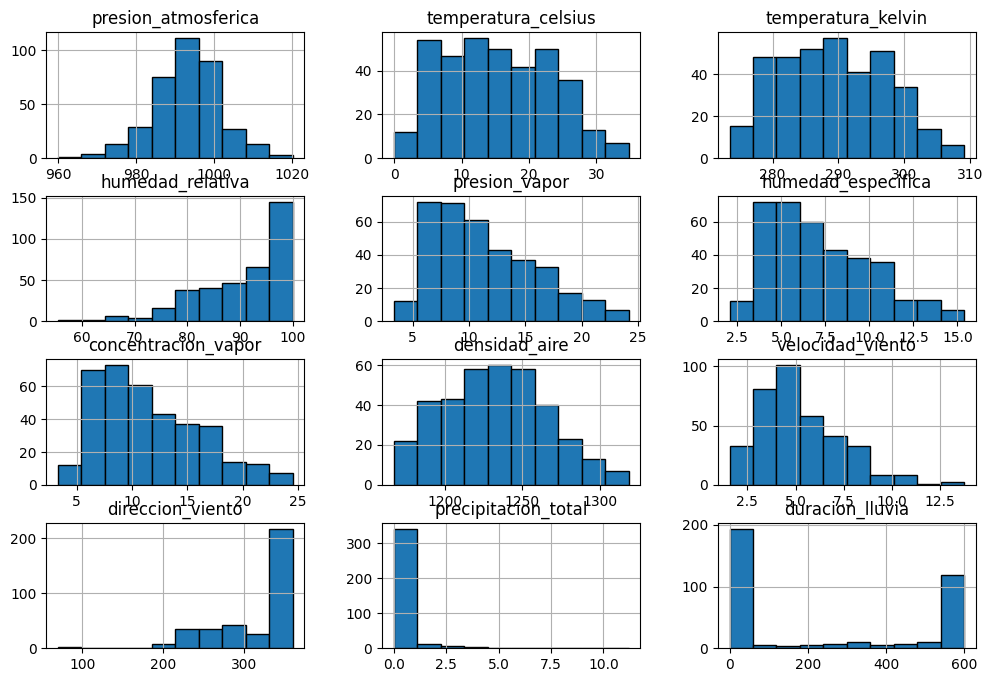

In [ ]:
indicadores_diarios_df.hist(figsize=(12, 8), edgecolor="black")

8. Utiliza el dataframe de indicadores diarios para crear un nuevo dataframe `indicadores_mensuales`. Para ello:
- Crea una nueva columna `mes` a partir de la fecha que se encuentra en el índice.
- Haciendo uso de `groupby()`, calcula los promedios mensuales y conserva únicamente las columnas `humedad_relativa`, `temperatura_celsius` y `velocidad_viento` en el nuevo dataframe.

**CREO LA NUEVA COLUMNA MES**

In [ ]:
#Creo el nuevo DataFrame asignando la columna 'mes'
indicadores_mensuales_df = indicadores_diarios_df.assign(mes=pd.to_datetime(indicadores_diarios_df.index).month)

#Verifico el resultado
indicadores_mensuales_df.head()

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,mes
fecha,,,,,,,,,,,,,
2020-01-01,1008.89,4.58,277.27,95.0,5.81,3.60,5.77,1298.02,1.91,356.9,0.0,0.0,1
2020-01-02,983.52,13.11,288.13,87.8,11.61,7.43,11.89,1208.07,8.70,345.4,0.2,600.0,1
2020-01-03,973.09,10.88,286.46,79.6,7.22,4.63,7.43,1215.51,10.56,240.5,0.1,170.0,1
2020-01-04,1000.05,8.91,282.79,80.5,3.84,2.40,3.85,1301.02,3.12,346.3,0.0,0.0,1
2020-01-05,977.99,14.20,289.36,86.5,9.85,6.30,10.09,1207.03,9.04,238.3,0.5,600.0,1


**AGRUPO POR MES Y FILTRO LAS COLUMNAS DE INTERES**

In [ ]:
#Defino las columnas que se desean conservar
columnas_interes = ["humedad_relativa", "temperatura_celsius", "velocidad_viento"]

# Agrupo por la columna 'mes', calculo la media (.mean()) y filtro las columnas
indicadores_mensuales_df = (indicadores_mensuales_df.groupby("mes")[columnas_interes].mean().reset_index())

#resultado final
indicadores_mensuales_df

,mes,humedad_relativa,temperatura_celsius,velocidad_viento
0,1,89.117097,10.369355,5.286129
1,2,88.497586,11.839655,6.760345
2,3,85.695484,11.842258,5.708065
3,4,84.595000,15.883000,5.403000
4,5,88.799355,16.270000,4.896774
5,6,92.504000,20.031667,5.087667
6,7,86.870968,21.082258,4.262903
7,8,93.273871,21.332581,4.885484
8,9,94.503333,19.773333,4.812000
9,10,95.853871,14.087097,5.647097


9. Construye el mismo dataframe mensual, pero esta vez utilizando la función `pivot_table()`.
- Añade la columna `indice_calor` usando la fórmula de Thom (*Temperature - Humidity Index*, TDI):
> `temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4`

**CONSTRUYO LA TABLA AHORA CON pivot_table()**

In [ ]:
# Reviso el indice para convertirlo. en DATETIME
indicadores_diarios_df.index = pd.to_datetime(indicadores_diarios_df.index)

# Defino las columnas de interés
columnas_interes = ["humedad_relativa", "temperatura_celsius", "velocidad_viento"]

# Construyo el nuevo DataFrame usando pivot_table()
indicadores_mensuales_df = pd.pivot_table(indicadores_diarios_df,index=indicadores_diarios_df.index.to_period('M'),values=columnas_interes,aggfunc='mean').reset_index()

# Renombro la primera columna resultante a 'mes'

indicadores_mensuales_df.rename(columns={indicadores_mensuales_df.columns[0]: 'mes'}, inplace=True)
print(indicadores_mensuales_df)

        mes  humedad_relativa  temperatura_celsius  velocidad_viento
0   2020-01         89.117097            10.369355          5.286129
1   2020-02         88.497586            11.839655          6.760345
2   2020-03         85.695484            11.842258          5.708065
3   2020-04         84.595000            15.883000          5.403000
4   2020-05         88.799355            16.270000          4.896774
5   2020-06         92.504000            20.031667          5.087667
6   2020-07         86.870968            21.082258          4.262903
7   2020-08         93.273871            21.332581          4.885484
8   2020-09         94.503333            19.773333          4.812000
9   2020-10         95.853871            14.087097          5.647097
10  2020-11         94.883333            11.062000          4.799000
11  2020-12         95.985161            10.499355          5.462903


**AÑADO LA COLUMNA indice_calor**

In [ ]:
indicadores_mensuales_df['indice_calor'] = (
    indicadores_mensuales_df['temperatura_celsius'] + (0.33 * indicadores_mensuales_df['humedad_relativa']) - (0.7 * indicadores_mensuales_df['velocidad_viento']) - 4)

**VERIFICO QUE ESTE TODO CORRECTO**

In [ ]:
print(indicadores_mensuales_df)

        mes  humedad_relativa  temperatura_celsius  velocidad_viento  \
0   2020-01         89.117097            10.369355          5.286129   
1   2020-02         88.497586            11.839655          6.760345   
2   2020-03         85.695484            11.842258          5.708065   
3   2020-04         84.595000            15.883000          5.403000   
4   2020-05         88.799355            16.270000          4.896774   
5   2020-06         92.504000            20.031667          5.087667   
6   2020-07         86.870968            21.082258          4.262903   
7   2020-08         93.273871            21.332581          4.885484   
8   2020-09         94.503333            19.773333          4.812000   
9   2020-10         95.853871            14.087097          5.647097   
10  2020-11         94.883333            11.062000          4.799000   
11  2020-12         95.985161            10.499355          5.462903   

    indice_calor  
0      32.077706  
1      32.311617  
2     

10. Recuerda que de las cuatro funciones estudiadas para manipular la estructura del dataframe:
- `melt/pivot` hacen las transformaciones de manera controlada, es decir puedes
definir por medio de sus parámetros qué variables quedarán como índices, columnas y valores.
- `stack/unstack` la conversión se aplica siempre sobre los niveles inferiores de index/columns.
- Convierte el dataframe del ejercicio anterior a formato largo usando: `melt()` y `stack()` y comenta las diferencias.

**10.1 UTILIZO melt()**

In [ ]:
df_melted = indicadores_mensuales_df.melt(
    id_vars=['mes'],
    var_name='parametro',
    value_name='valor'
)

# Mostrar los primeros resultados ordenados por mes
print(df_melted.head(20))

        mes            parametro      valor
0   2020-01     humedad_relativa  89.117097
1   2020-02     humedad_relativa  88.497586
2   2020-03     humedad_relativa  85.695484
3   2020-04     humedad_relativa  84.595000
4   2020-05     humedad_relativa  88.799355
5   2020-06     humedad_relativa  92.504000
6   2020-07     humedad_relativa  86.870968
7   2020-08     humedad_relativa  93.273871
8   2020-09     humedad_relativa  94.503333
9   2020-10     humedad_relativa  95.853871
10  2020-11     humedad_relativa  94.883333
11  2020-12     humedad_relativa  95.985161
12  2020-01  temperatura_celsius  10.369355
13  2020-02  temperatura_celsius  11.839655
14  2020-03  temperatura_celsius  11.842258
15  2020-04  temperatura_celsius  15.883000
16  2020-05  temperatura_celsius  16.270000
17  2020-06  temperatura_celsius  20.031667
18  2020-07  temperatura_celsius  21.082258
19  2020-08  temperatura_celsius  21.332581


**10.1 APLICO stack()**

In [ ]:
# Establezco 'mes' como el índice del DataFrame
df_indexed = indicadores_mensuales_df.set_index('mes')

# Aplico stack() para comprimir las columnas climáticas hacia el índice
df_stacked = df_indexed.stack()

# Renombro las columnas generadas automáticamente
df_stacked_clean.columns = ['mes', 'parametro', 'valor']

print(df_stacked_clean.head(20))

        mes            parametro      valor
0   2020-01     humedad_relativa  89.117097
1   2020-01  temperatura_celsius  10.369355
2   2020-01     velocidad_viento   5.286129
3   2020-01         indice_calor  32.077706
4   2020-02     humedad_relativa  88.497586
5   2020-02  temperatura_celsius  11.839655
6   2020-02     velocidad_viento   6.760345
7   2020-02         indice_calor  32.311617
8   2020-03     humedad_relativa  85.695484
9   2020-03  temperatura_celsius  11.842258
10  2020-03     velocidad_viento   5.708065
11  2020-03         indice_calor  32.126123
12  2020-04     humedad_relativa  84.595000
13  2020-04  temperatura_celsius  15.883000
14  2020-04     velocidad_viento   5.403000
15  2020-04         indice_calor  36.017250
16  2020-05     humedad_relativa  88.799355
17  2020-05  temperatura_celsius  16.270000
18  2020-05     velocidad_viento   4.896774
19  2020-05         indice_calor  38.146045


**stack() APILA LOS DIFERENTES PARÁMETROS PARA CADA MES, MIENTRAS QUE melt()  APILA LOS VALORES DE CADA PARAMETRO PARA TODOS LOS MESES Y LUEGO LOS DEL SIGUIENTE PARÁMETRO.**

---

**Declaración de uso de IA**

Si aplica, deberá indicarse la herramienta y el modelo empleado en la entrega, así como la finalidad de su uso (generación de código / depuración / optimización).

Por ejemplo:

*   OpenAI. (2026). *ChatGPT (basado en GPT-4)* [Modelo de lenguaje grande], utilizado para generación de código y depuración. https://chat.openai.com/

---